# Notebook 03 — Map Literacy, CRS and GeoPandas
## จากตารางข้อมูลสิ่งแวดล้อมสู่ข้อมูลเชิงพื้นที่

**ระดับผู้เรียน:** ปริญญาตรีปี 3–4 / ปริญญาโท  
**กลุ่มสาขา:** สิ่งแวดล้อม ภูมิศาสตร์ ภูมิสารสนเทศ อุตุนิยมวิทยา  
**Platform:** Google Colab

---

# คำถามหลักของบทนี้

Notebook 02 ทำให้เรารู้ว่า:

```text
สถานีใด
วันใด
PM2.5 เท่าไร
```

แต่ยังมีคำถามสำคัญ:

> สถานีนั้นอยู่ที่ไหน?

Notebook 03 จะเปลี่ยนแนวคิดจาก:

```text
Table
station_id | latitude | longitude
```

ไปเป็น:

```text
Spatial Data
Attribute + Geometry + CRS
```

และเริ่มใช้:

```text
GeoPandas
GeoDataFrame
Point
Polygon
CRS
EPSG:4326
EPSG:32647
```

---

# Course progression

```text
Notebook 01
Canonical Dataset
      ↓
Notebook 02
Pandas + PM2.5
      ↓
Notebook 03
Map Literacy + CRS + GeoPandas
      ↓
Notebook 04
Spatial Join + Distance + Station Matching
      ↓
Notebook 05
Spatiotemporal Environmental Analysis
      ↓
Notebook 06
Spatial Statistics
```

# Learning Outcomes

เมื่อจบ Notebook 03 นิสิตควรสามารถ:

1. อธิบายว่า GIS คืออะไรในบริบทข้อมูลสิ่งแวดล้อม
2. แยกความแตกต่างระหว่าง attribute และ geometry
3. อธิบาย Point, Line และ Polygon
4. เข้าใจ longitude และ latitude
5. สร้าง Point จาก longitude/latitude ด้วย GeoPandas
6. อธิบาย GeoDataFrame ได้
7. อ่าน GeoPackage ได้
8. ตรวจ CRS ด้วย `.crs`
9. อธิบาย EPSG:4326 ได้
10. อธิบายความแตกต่างระหว่าง geographic CRS และ projected CRS
11. เข้าใจว่าทำไมระยะทางใน EPSG:4326 ไม่ควรตีความเป็นเมตร
12. reproject ข้อมูลด้วย `.to_crs()`
13. ใช้ UTM 47N สำหรับกรณีศึกษาสระบุรี–ลพบุรี–นครนายก
14. ตรวจ geometry validity และ map bounds
15. overlay Point กับ Polygon เพื่ออ่านแผนที่
16. สร้างแผนที่สถานี PCD และสถานีอุตุนิยมวิทยา
17. เลือก subset จังหวัดจาก attributes
18. สร้างแผนที่หลายระดับ จังหวัด–อำเภอ–ตำบล
19. อธิบายข้อจำกัดของแผนที่สถานีตรวจวัด
20. เตรียมข้อมูลสำหรับ spatial join และ distance analysis ใน Notebook 04

# 3.1 GIS คืออะไร?

ในบริบทของ course นี้ GIS ไม่ได้เริ่มจาก software

แต่เริ่มจากคำถาม:

> “ข้อมูลสิ่งแวดล้อมนี้เกิดขึ้นที่ตำแหน่งใด?”

ตัวอย่าง:

```text
PM2.5 = 55 µg/m³
```

ตัวเลขนี้ยังไม่มีบริบทเชิงพื้นที่

แต่ถ้าเรารู้:

```text
station_id = ...
latitude   = ...
longitude  = ...
province   = Saraburi
```

ข้อมูลจะเริ่มตอบคำถามด้านภูมิศาสตร์ได้

---

## Spatial data = Attribute + Geometry + CRS

### Attribute

ข้อมูลเชิงบรรยาย เช่น:

```text
station_id
station_name
PM2.5
province
date
```

### Geometry

ตำแหน่งหรือรูปร่าง:

```text
Point
Line
Polygon
```

### CRS

ระบบที่บอกว่า coordinate มีความหมายอย่างไร

```text
EPSG:4326
EPSG:32647
...
```

ถ้าขาด CRS ตัวเลข coordinate อาจตีความผิดได้

# 3.2 Point, Line and Polygon

## Point

ใช้แทนสิ่งที่มีตำแหน่งเฉพาะ:

```text
PCD air-quality station
meteorological station
rain gauge
weather radar
sampling point
```

## Line

ใช้แทนสิ่งที่มีเส้นทาง:

```text
road
river
transport route
storm track
```

## Polygon

ใช้แทนพื้นที่:

```text
province
amphoe
tambon
watershed
land-use zone
protected area
```

ใน Notebook นี้เราจะใช้หลัก ๆ:

```text
Point + Polygon
```

In [1]:
# CELL 1 — Install GIS packages

!pip -q install -U \
    geopandas \
    pyogrio \
    shapely \
    pyproj \
    mapclassify \
    folium \
    openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 880.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.0/479.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [2]:
# CELL 2 — Mount Google Drive

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [3]:
# CELL 3 — Imports

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyogrio

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning
)

print("pandas    :", pd.__version__)
print("GeoPandas :", gpd.__version__)

pandas    : 3.0.5
GeoPandas : 1.1.4


# 3.3 Input Data

Notebook นี้ใช้ข้อมูลจาก 2 แหล่งภายใน course เท่านั้น:

### Canonical spatial dataset จาก Notebook 01

```text
environmental_gis_course.gpkg
pcd_air4thai_stations.csv
ogimet_wmo_stations_from_course_sources.csv
```

### PM₂.₅ daily output จาก Notebook 02

```text
02_pcd_pm25_daily_2021_2025.csv.gz
```

ไม่มีการดาวน์โหลด spatial data จากเว็บไซต์ภายนอกอีก

In [4]:
# CELL 4 — Paths

DATASET_VERSION = "v1"

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Teaching_PCD_Environmental_GIS"
)

DATASET_DIR = (
    BASE_DIR
    / "01_course_data"
    / DATASET_VERSION
    / "dataset"
)

NOTEBOOK02_OUTPUT = (
    BASE_DIR
    / "02_output"
    / "Notebook_02"
)

OUTPUT_DIR = (
    BASE_DIR
    / "02_output"
    / "Notebook_03"
)

FIGURE_DIR = (
    BASE_DIR
    / "03_figures"
    / "Notebook_03"
)

for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


if not DATASET_DIR.exists():

    raise FileNotFoundError(
        "Canonical dataset folder not found. "
        "Run Notebook 01 first."
    )


print("Canonical data:")
print(DATASET_DIR)

print("\nNotebook 02 output:")
print(NOTEBOOK02_OUTPUT)

Canonical data:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset

Notebook 02 output:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_02


In [5]:
# CELL 5 — Locate required files

def find_unique_file(
    root,
    filename,
    required=True,
):
    matches = list(
        Path(
            root
        ).rglob(
            filename
        )
    )

    if len(
        matches
    ) == 1:

        return matches[
            0
        ]

    if len(
        matches
    ) == 0:

        if required:

            raise FileNotFoundError(
                f"Required file not found: {filename}"
            )

        return None

    raise RuntimeError(
        f"Multiple copies found for {filename}: "
        + str(
            matches
        )
    )


COURSE_GPKG = find_unique_file(
    DATASET_DIR,
    "environmental_gis_course.gpkg",
)

PCD_STATION_CSV = find_unique_file(
    DATASET_DIR,
    "pcd_air4thai_stations.csv",
)

OGIMET_STATION_CSV = find_unique_file(
    DATASET_DIR,
    "ogimet_wmo_stations_from_course_sources.csv",
)

PM25_DAILY_FILE = find_unique_file(
    NOTEBOOK02_OUTPUT,
    "02_pcd_pm25_daily_2021_2025.csv.gz",
    required=False,
)


print("GeoPackage:")
print(COURSE_GPKG)

print("\nPCD station CSV:")
print(PCD_STATION_CSV)

print("\nOGIMET station CSV:")
print(OGIMET_STATION_CSV)

print("\nPM2.5 daily:")
print(PM25_DAILY_FILE)

GeoPackage:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset/processed/environmental_gis_course.gpkg

PCD station CSV:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset/processed/pcd_air4thai_stations.csv

OGIMET station CSV:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset/processed/ogimet_wmo_stations_from_course_sources.csv

PM2.5 daily:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_02/02_pcd_pm25_daily_2021_2025.csv.gz


# 3.4 GeoPackage ก่อนเริ่มทำแผนที่

GeoPackage (`.gpkg`) เป็น spatial database ในไฟล์เดียว

course dataset ถูกเตรียมให้มี layers เช่น:

```text
province
amphoe
tambon
pcd_stations
met_stations_thailand
ogimet_stations
```

เราจะตรวจ layer names ก่อนอ่านข้อมูล

In [6]:
# CELL 6 — List GeoPackage layers

layer_info = pyogrio.list_layers(
    COURSE_GPKG
)

layer_table = pd.DataFrame(
    layer_info,
    columns=[
        "layer",
        "geometry_type",
    ],
)

display(
    layer_table
)

,layer,geometry_type
0,province,MultiPolygon
1,amphoe,MultiPolygon
2,tambon,MultiPolygon
3,pcd_stations,Point
4,met_stations_thailand,Point
5,ogimet_stations,Point


In [7]:
# CELL 7 — Read canonical GIS layers

REQUIRED_LAYERS = [
    "province",
    "amphoe",
    "tambon",
    "pcd_stations",
    "ogimet_stations",
]


available_layers = set(
    layer_table[
        "layer"
    ].astype(str)
)


missing_layers = [
    layer
    for layer
    in REQUIRED_LAYERS
    if layer
    not in available_layers
]


if missing_layers:

    raise RuntimeError(
        "Required GeoPackage layers missing: "
        + ", ".join(
            missing_layers
        )
    )


province = gpd.read_file(
    COURSE_GPKG,
    layer="province",
)

amphoe = gpd.read_file(
    COURSE_GPKG,
    layer="amphoe",
)

tambon = gpd.read_file(
    COURSE_GPKG,
    layer="tambon",
)

pcd_gpkg = gpd.read_file(
    COURSE_GPKG,
    layer="pcd_stations",
)

ogimet_gpkg = gpd.read_file(
    COURSE_GPKG,
    layer="ogimet_stations",
)


print(
    "Province:",
    province.shape
)

print(
    "Amphoe:",
    amphoe.shape
)

print(
    "Tambon:",
    tambon.shape
)

print(
    "PCD stations:",
    pcd_gpkg.shape
)

print(
    "OGIMET stations:",
    ogimet_gpkg.shape
)

Province: (77, 12)
Amphoe: (928, 26)
Tambon: (7425, 32)
PCD stations: (173, 21)
OGIMET stations: (130, 26)


# 3.5 DataFrame vs GeoDataFrame

Pandas `DataFrame`:

```text
station_id
latitude
longitude
```

GeoPandas `GeoDataFrame`:

```text
station_id
latitude
longitude
geometry
CRS
```

คอลัมน์ `geometry` ทำให้ GeoPandas รู้ว่า row นั้นเป็นตำแหน่งหรือรูปร่างใด

ลองตรวจชนิดข้อมูล

In [8]:
# CELL 8 — Inspect GeoDataFrame structure

print(
    "Object type:"
)

print(
    type(
        pcd_gpkg
    )
)

print(
    "\nGeometry column:"
)

print(
    pcd_gpkg.geometry.name
)

print(
    "\nGeometry types:"
)

print(
    pcd_gpkg.geometry.geom_type.value_counts()
)

print(
    "\nCRS:"
)

print(
    pcd_gpkg.crs
)


display(
    pcd_gpkg.head(
        5
    )
)

Object type:
<class 'geopandas.geodataframe.GeoDataFrame'>

Geometry column:
geometry

Geometry types:
Point    173
Name: count, dtype: int64

CRS:
EPSG:4326


,station_id,station_name_th,station_name_en,area_th,area_en,station_type,latitude,longitude,coordinate_source_type,coordinate_source_file,...,province_code,province_name_en,province_name_th,amphoe_code,amphoe_name_en,amphoe_name_th,tambon_code,tambon_name_en,tambon_name_th,geometry
0,119t,สวนสาธารณะธารา,Thara Public Park,"ต.ปากน้ำ อ.เมือง, กระบี่","Pak Nam Subdistrict, Mueang District, Krabi",GROUND,8.050624,98.918049,Air4Thai_public_station_metadata,https://air4thai.pcd.go.th/services/getNewAQI_...,...,<NA>,Krabi,กระบี่,TH8101,Mueang Krabi,เมืองกระบี่,TH810115,Sai Thai,à¹à¸ªà¹à¸à¸¢,POINT (98.91805 8.05062)
1,02t,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bansomdejchaopraya Rajabhat University,"แขวงหิรัญรูจี เขตธนบุรี, กรุงเทพฯ","Hiran Ruchi, Khet Thon Buri, Bangkok",GROUND,13.732846,100.487662,Air4Thai_public_station_metadata,https://air4thai.pcd.go.th/services/getNewAQI_...,...,<NA>,Bangkok,กรุงเทพมหานคร,TH1015,Thon Buri,ธนบุรี,TH101502,Hiranruchi,à¸«à¸´à¸£à¸±à¸à¸£à¸¹à¸à¸µ,POINT (100.48766 13.73285)
2,03t,ริมถนนทางหลวงหมายเลข 3902,Highway NO.3902 km.13 +600,"ริมถนนกาญจนาภิเษก เขตบางขุนเทียน, กรุงเทพฯ","Kanchanaphisek Rd, Bang Khun Thian, Bangkok",GROUND,13.636514,100.414262,Air4Thai_public_station_metadata,https://air4thai.pcd.go.th/services/getNewAQI_...,...,<NA>,Bangkok,กรุงเทพมหานคร,TH1021,Bang Khun Thian,บางขุนเทียน,TH102107,Samae Dam,à¹à¸ªà¸¡à¸à¸³,POINT (100.41426 13.63651)
3,05t,กรมอุตุนิยมวิทยาบางนา,Thai Meteorological Department,"แขวงบางนา เขตบางนา, กรุงเทพฯ","Bang Na, Khet Bang Na, Bangkok",GROUND,13.666183,100.605742,Air4Thai_public_station_metadata,https://air4thai.pcd.go.th/services/getNewAQI_...,...,<NA>,Bangkok,กรุงเทพมหานคร,TH1047,Bang Na,บางนา,TH104701,Bang Na,à¸à¸²à¸à¸à¸²,POINT (100.60574 13.66618)
4,12t,โรงเรียนนนทรีวิทยา,Nonsi Witthaya School,"แขวงช่องนนทรี เขตยานนาวา, กรุงเทพฯ","Chong Nonsi, Khet Yannawa, Bangkok",GROUND,13.708067,100.547333,Air4Thai_public_station_metadata,https://air4thai.pcd.go.th/services/getNewAQI_...,...,<NA>,Bangkok,กรุงเทพมหานคร,TH1012,Yan Nawa,ยานนาวา,TH101203,Chong Nonsi,à¸à¹à¸­à¸à¸à¸à¸à¸£à¸µ,POINT (100.54733 13.70807)


# 3.6 สร้าง Point จาก Longitude และ Latitude

แม้ course จะมี `pcd_stations` layer ให้แล้ว
เราจะสร้าง Point ใหม่จาก CSV เพื่อเรียนหลักการ

สมมติ:

```text
longitude = 100.50
latitude  = 14.80
```

GeoPandas ใช้:

```python
gpd.points_from_xy(
    longitude,
    latitude
)
```

จำง่าย:

```text
X = Longitude
Y = Latitude
```

ไม่ใช่กลับกัน

In [9]:
# CELL 9 — Read PCD station CSV

pcd_table = pd.read_csv(
    PCD_STATION_CSV,
    dtype={
        "station_id":
            "string"
    },
)


required_coordinate_fields = [
    "longitude",
    "latitude",
]


missing_coordinate_fields = [
    field
    for field
    in required_coordinate_fields
    if field
    not in pcd_table.columns
]


if missing_coordinate_fields:

    raise KeyError(
        "Missing coordinate fields: "
        + ", ".join(
            missing_coordinate_fields
        )
    )


pcd_table[
    "longitude"
] = pd.to_numeric(
    pcd_table[
        "longitude"
    ],
    errors="coerce",
)

pcd_table[
    "latitude"
] = pd.to_numeric(
    pcd_table[
        "latitude"
    ],
    errors="coerce",
)


display(
    pcd_table[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "longitude",
                "latitude",
            ]
            if c
            in pcd_table.columns
        ]
    ].head(
        10
    )
)

,station_id,station_name_en,longitude,latitude
0,119t,Thara Public Park,98.918049,8.050624
1,02t,Bansomdejchaopraya Rajabhat University,100.487662,13.732846
2,03t,Highway NO.3902 km.13 +600,100.414262,13.636514
3,05t,Thai Meteorological Department,100.605742,13.666183
4,12t,Nonsi Witthaya School,100.547333,13.708067
5,50t,Chulalongkorn Hospital,100.536501,13.729852
6,52t,Thonburi Power Sub-Station,100.486568,13.727622
7,53t,Chokchai Police Station,100.593030,13.795425
8,54t,National Housing Authority Dindaeng,100.550200,13.762517
9,59t,The Government Public Relations Department,100.540489,13.783185


In [10]:
# CELL 10 — Create Point geometry from station CSV

pcd_from_csv = gpd.GeoDataFrame(
    pcd_table.copy(),
    geometry=gpd.points_from_xy(
        pcd_table[
            "longitude"
        ],
        pcd_table[
            "latitude"
        ],
    ),
    crs="EPSG:4326",
)


print(
    "Type:",
    type(
        pcd_from_csv
    )
)

print(
    "CRS:",
    pcd_from_csv.crs
)

print(
    "Geometry type:"
)

print(
    pcd_from_csv.geometry.geom_type.value_counts()
)


display(
    pcd_from_csv[
        [
            c
            for c
            in [
                "station_id",
                "longitude",
                "latitude",
                "geometry",
            ]
            if c
            in pcd_from_csv.columns
        ]
    ].head(
        10
    )
)

Type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:4326
Geometry type:
Point    173
Name: count, dtype: int64


,station_id,longitude,latitude,geometry
0,119t,98.918049,8.050624,POINT (98.91805 8.05062)
1,02t,100.487662,13.732846,POINT (100.48766 13.73285)
2,03t,100.414262,13.636514,POINT (100.41426 13.63651)
3,05t,100.605742,13.666183,POINT (100.60574 13.66618)
4,12t,100.547333,13.708067,POINT (100.54733 13.70807)
5,50t,100.536501,13.729852,POINT (100.5365 13.72985)
6,52t,100.486568,13.727622,POINT (100.48657 13.72762)
7,53t,100.593030,13.795425,POINT (100.59303 13.79542)
8,54t,100.550200,13.762517,POINT (100.5502 13.76252)
9,59t,100.540489,13.783185,POINT (100.54049 13.78318)


# Checkpoint 1 — Longitude / Latitude

ตอบก่อนทำต่อ:

```text
longitude เป็นแกน X หรือ Y?
latitude เป็นแกน X หรือ Y?
```

คำตอบ:

```text
X = Longitude
Y = Latitude
```

ถ้าสลับกัน สถานีอาจไปปรากฏผิดประเทศหรือผิดทวีป

ดังนั้น coordinate QC เป็นขั้นตอนสำคัญก่อนทำแผนที่

# 3.7 ตรวจว่าการสร้าง Point ใหม่ตรงกับ canonical layer หรือไม่

นี่เป็นการสอนแนวคิด reproducibility

เรามี:

```text
PCD station CSV
    ↓ create geometry
pcd_from_csv
```

และมี:

```text
canonical GeoPackage
    ↓
pcd_gpkg
```

ทั้งสองควรมี station IDs และ coordinates สอดคล้องกัน

In [11]:
# CELL 11 — Compare CSV-built points with GeoPackage points

pcd_from_csv[
    "station_id"
] = (
    pcd_from_csv[
        "station_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.lower()
)


pcd_gpkg[
    "station_id"
] = (
    pcd_gpkg[
        "station_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.lower()
)


csv_ids = set(
    pcd_from_csv[
        "station_id"
    ]
    .dropna()
)

gpkg_ids = set(
    pcd_gpkg[
        "station_id"
    ]
    .dropna()
)


point_comparison = pd.DataFrame([
    {
        "check":
            "CSV point rows",

        "value":
            len(
                pcd_from_csv
            ),
    },

    {
        "check":
            "GeoPackage point rows",

        "value":
            len(
                pcd_gpkg
            ),
    },

    {
        "check":
            "station IDs only in CSV",

        "value":
            len(
                csv_ids
                - gpkg_ids
            ),
    },

    {
        "check":
            "station IDs only in GeoPackage",

        "value":
            len(
                gpkg_ids
                - csv_ids
            ),
    },
])


display(
    point_comparison
)

,check,value
0,CSV point rows,173
1,GeoPackage point rows,173
2,station IDs only in CSV,0
3,station IDs only in GeoPackage,0


# 3.8 อ่านแผนที่อย่างเป็นระบบ

ก่อน plot ต้องรู้ 5 เรื่อง:

```text
1. What?     ตัวแปร/สิ่งที่แสดงคืออะไร
2. Where?    พื้นที่ไหน
3. Geometry? Point/Line/Polygon
4. CRS?      ระบบพิกัดอะไร
5. Scale?    ระดับประเทศ จังหวัด หรือท้องถิ่น
```

แผนที่ที่ดูสวยแต่ไม่ตอบ 5 คำถามนี้อาจทำให้ตีความผิดได้

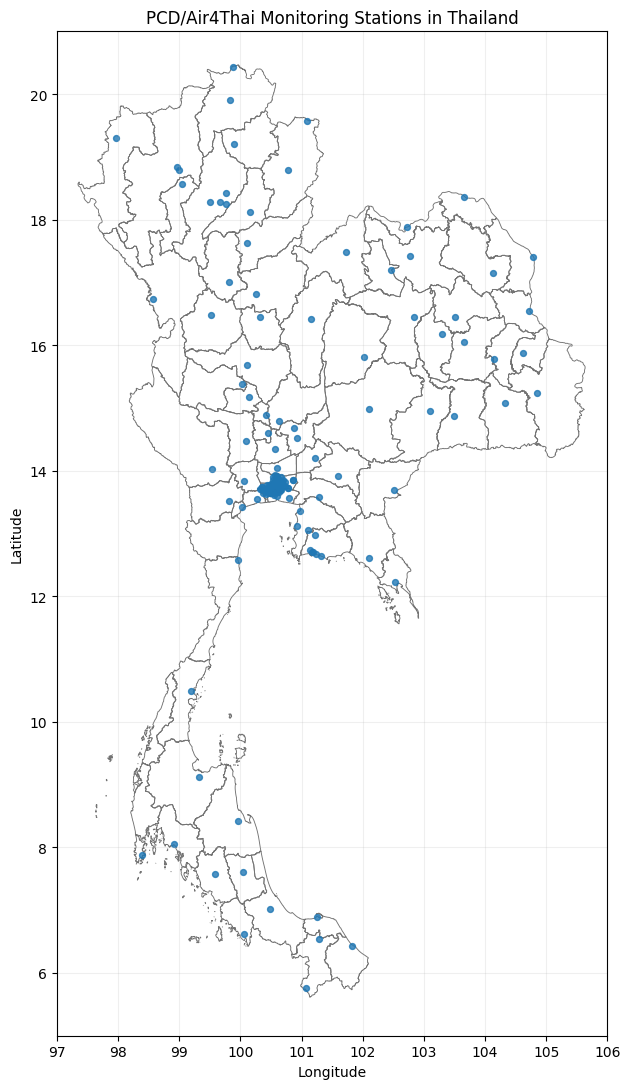

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/03_figures/Notebook_03/03_PCD_stations_Thailand.png


In [12]:
# CELL 12 — National PCD station map

fig, ax = plt.subplots(
    figsize=(
        8.5,
        11,
    )
)

province.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.45",
    linewidth=0.65,
)

pcd_gpkg.plot(
    ax=ax,
    markersize=18,
    alpha=0.8,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "PCD/Air4Thai Monitoring Stations in Thailand"
)

ax.set_xlim(
    97,
    106,
)

ax.set_ylim(
    5,
    21,
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

PCD_NATIONAL_MAP = (
    FIGURE_DIR
    / "03_PCD_stations_Thailand.png"
)

fig.savefig(
    PCD_NATIONAL_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    PCD_NATIONAL_MAP
)

# ตีความแผนที่สถานีอย่างถูกต้อง

จากแผนที่นี้เราสามารถพูดว่า:

> จุดเหล่านี้แสดงตำแหน่งสถานีตรวจวัด PCD/Air4Thai ใน canonical dataset

แต่ยังไม่ควรพูดว่า:

> พื้นที่ที่ไม่มีจุด = ไม่มีมลพิษ

เพราะ “ไม่มี station” หมายถึง:

```text
ไม่มี monitoring point ใน dataset
```

ไม่ใช่:

```text
pollution = 0
```

นี่เป็นแนวคิดเรื่อง **monitoring-network geography**

# 3.9 CRS — Coordinate Reference System

ตัวเลข:

```text
100.5, 14.8
```

ไม่มีความหมายทาง GIS ที่สมบูรณ์จนกว่าเราจะรู้ CRS

ใน course canonical dataset:

```text
CRS = EPSG:4326
```

EPSG:4326 เป็น geographic coordinate system ที่ใช้:

```text
longitude
latitude
```

หน่วยหลักคือ:

```text
degree
```

ไม่ใช่เมตร

In [13]:
# CELL 13 — CRS inventory

crs_inventory = pd.DataFrame([
    {
        "layer":
            "province",

        "crs":
            str(
                province.crs
            ),
    },

    {
        "layer":
            "amphoe",

        "crs":
            str(
                amphoe.crs
            ),
    },

    {
        "layer":
            "tambon",

        "crs":
            str(
                tambon.crs
            ),
    },

    {
        "layer":
            "pcd_stations",

        "crs":
            str(
                pcd_gpkg.crs
            ),
    },

    {
        "layer":
            "ogimet_stations",

        "crs":
            str(
                ogimet_gpkg.crs
            ),
    },
])


display(
    crs_inventory
)

,layer,crs
0,province,EPSG:4326
1,amphoe,EPSG:4326
2,tambon,EPSG:4326
3,pcd_stations,EPSG:4326
4,ogimet_stations,EPSG:4326


# 3.10 Geographic CRS vs Projected CRS

## Geographic CRS

ตัวอย่าง:

```text
EPSG:4326
```

ใช้:

```text
longitude / latitude
degree
```

เหมาะกับ:

- เก็บตำแหน่งทั่วโลก
- exchange data
- national overview
- web/API coordinates

---

## Projected CRS

เปลี่ยนผิวโลกเป็นระนาบ

เช่น:

```text
UTM
```

หน่วยโดยทั่วไป:

```text
metre
```

เหมาะกับ:

- distance
- buffer
- area
- local/regional metric analysis

---

## หลักสำคัญ

> Plot ใน EPSG:4326 ได้  
> แต่ไม่ควรใช้ระยะทางในหน่วย degree แล้วเรียกว่า km

# 3.11 การทดลอง: ทำไม distance ใน EPSG:4326 จึงอันตราย

ลองเลือกสถานี PCD 2 จุดแรก

ถ้าคำนวณ:

```python
point1.distance(point2)
```

ขณะ CRS = EPSG:4326

ค่าที่ได้อยู่ในหน่วยของ coordinate system:

```text
degree
```

ไม่ใช่ kilometre

In [14]:
# CELL 14 — Demonstrate distance in geographic coordinates

pcd_valid_points = (
    pcd_gpkg[
        pcd_gpkg.geometry.notna()
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


if len(
    pcd_valid_points
) < 2:

    raise RuntimeError(
        "At least two PCD station points are required."
    )


point_a = pcd_valid_points.geometry.iloc[
    0
]

point_b = pcd_valid_points.geometry.iloc[
    1
]


distance_in_degrees = point_a.distance(
    point_b
)


print(
    "PCD CRS:",
    pcd_valid_points.crs
)

print(
    "Raw geometry distance:",
    distance_in_degrees
)

print(
    "\nInterpretation:"
)

print(
    "This value is in geographic-coordinate units "
    "(degrees), NOT kilometres."
)

PCD CRS: EPSG:4326
Raw geometry distance: 5.895026340086099

Interpretation:
This value is in geographic-coordinate units (degrees), NOT kilometres.


# ห้ามทำแบบนี้

```python
distance_km = point1.distance(point2) / 1000
```

เมื่อ CRS ยังเป็น EPSG:4326

เพราะ:

```text
degree / 1000 ≠ kilometre
```

ต้องเปลี่ยนไป projected CRS ที่เหมาะสมก่อน
หรือใช้ geodesic-distance method

# 3.12 Case Study: Saraburi – Lop Buri – Nakhon Nayok

จากนี้ใช้ 3 จังหวัดเป็น laboratory เชิงพื้นที่:

```text
Saraburi
Lop Buri
Nakhon Nayok
```

พื้นที่นี้อยู่บริเวณประมาณ:

```text
100–101°E
14–15°N
```

จึงเหมาะกับ:

```text
WGS 84 / UTM zone 47N
EPSG:32647
```

UTM zone 47N ครอบคลุม longitude ประมาณ:

```text
96°E – 102°E
```

จึงเหมาะกับกรณีศึกษานี้

แต่ไม่ได้หมายความว่า EPSG:32647 เหมาะที่สุดสำหรับทุกจุดทั่วประเทศไทย

In [15]:
# CELL 15 — Inspect province-name fields

province_name_fields = [
    column
    for column
    in province.columns
    if (
        "province"
        in column.lower()
        or "adm1"
        in column.lower()
        or "name"
        in column.lower()
    )
]


print(
    "Potential province-name fields:"
)

print(
    province_name_fields
)


display(
    province[
        [
            c
            for c
            in [
                "province_code",
                "province_name_en",
                "province_name_th",
            ]
            if c
            in province.columns
        ]
    ].head(
        10
    )
)

Potential province-name fields:
['ADM1_EN', 'ADM1_TH', 'province_code', 'province_name_en', 'province_name_th']


,province_code,province_name_en,province_name_th
0,<NA>,Bangkok,กรุงเทพมหานคร
1,<NA>,Samut Prakan,สมุทรปราการ
2,<NA>,Nonthaburi,นนทบุรี
3,<NA>,Pathum Thani,ปทุมธานี
4,<NA>,Phra Nakhon Si Ayutthaya,พระนครศรีอยุธยา
5,<NA>,Ang Thong,อ่างทอง
6,<NA>,Lop Buri,ลพบุรี
7,<NA>,Sing Buri,สิงห์บุรี
8,<NA>,Chai Nat,ชัยนาท
9,<NA>,Saraburi,สระบุรี


In [16]:
# CELL 16 — Select the three case-study provinces

CASE_PROVINCES = [
    "Saraburi",
    "Lop Buri",
    "Nakhon Nayok",
]


if (
    "province_name_en"
    not in province.columns
):

    raise KeyError(
        "province_name_en is not available in the province layer."
    )


case_provinces = (
    province[
        province[
            "province_name_en"
        ].isin(
            CASE_PROVINCES
        )
    ]
    .copy()
)


print(
    "Case provinces selected:",
    len(
        case_provinces
    )
)

display(
    case_provinces[
        [
            c
            for c
            in [
                "province_code",
                "province_name_en",
                "province_name_th",
            ]
            if c
            in case_provinces.columns
        ]
    ]
)

Case provinces selected: 3


,province_code,province_name_en,province_name_th
6,<NA>,Lop Buri,ลพบุรี
9,<NA>,Saraburi,สระบุรี
16,<NA>,Nakhon Nayok,นครนายก


In [17]:
# CELL 17 — Select PCD stations using existing province attributes

if (
    "province_name_en"
    not in pcd_gpkg.columns
):

    raise KeyError(
        "province_name_en is missing from canonical PCD station layer."
    )


case_pcd = (
    pcd_gpkg[
        pcd_gpkg[
            "province_name_en"
        ].isin(
            CASE_PROVINCES
        )
    ]
    .copy()
)


print(
    "PCD stations in the three case provinces:",
    len(
        case_pcd
    )
)


display(
    case_pcd[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "province_name_en",
                "latitude",
                "longitude",
            ]
            if c
            in case_pcd.columns
        ]
    ]
)

PCD stations in the three case provinces: 4


,station_id,station_name_en,province_name_en,latitude,longitude
95,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,14.204220,101.215090
131,99t,Meteorological Station Lopburi,Lop Buri,14.800032,100.628548
149,24t,Na Phralan Police Station,Saraburi,14.685833,100.871996
150,25t,Khao Noi Fire Station,Saraburi,14.526343,100.926047


## สำคัญ

Cell ก่อนหน้าใช้:

```text
province_name_en
```

ที่มีอยู่ใน canonical station metadata แล้ว

นี่เป็น **attribute filtering**

ไม่ใช่การพิสูจน์ด้วย geometry ใหม่ว่า station อยู่ใน province ใด

Notebook 04 จะทำ:

```text
Point + Polygon
    ↓
spatial join
```

แล้วเปรียบเทียบกับ attribute ที่เตรียมไว้

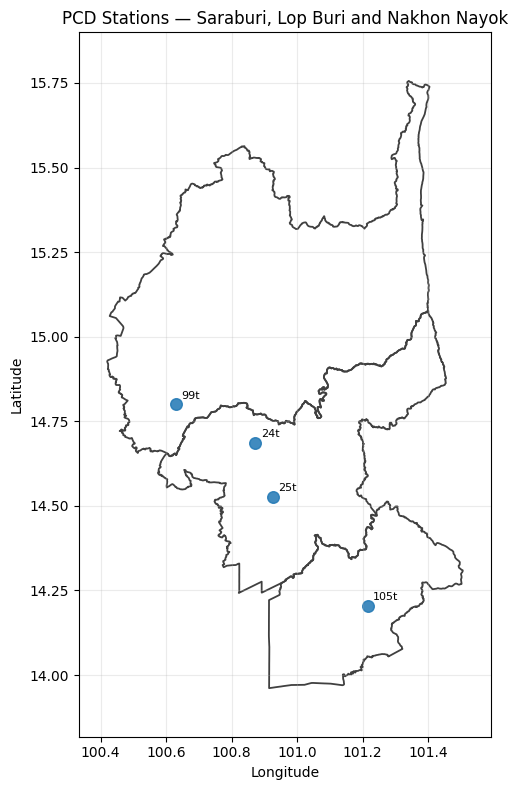

In [18]:
# CELL 18 — Three-province map in EPSG:4326

fig, ax = plt.subplots(
    figsize=(
        9,
        8,
    )
)

case_provinces.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.25",
    linewidth=1.3,
)

case_pcd.plot(
    ax=ax,
    markersize=70,
    alpha=0.85,
)


for _, row in case_pcd.iterrows():

    ax.annotate(
        str(
            row[
                "station_id"
            ]
        ),
        xy=(
            row.geometry.x,
            row.geometry.y,
        ),
        xytext=(
            4,
            4,
        ),
        textcoords="offset points",
        fontsize=8,
    )


xmin, ymin, xmax, ymax = (
    case_provinces.total_bounds
)


xpad = (
    xmax
    - xmin
) * 0.08

ypad = (
    ymax
    - ymin
) * 0.08


ax.set_xlim(
    xmin - xpad,
    xmax + xpad,
)

ax.set_ylim(
    ymin - ypad,
    ymax + ypad,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "PCD Stations — Saraburi, Lop Buri and Nakhon Nayok"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

CASE_MAP_4326 = (
    FIGURE_DIR
    / "03_case_provinces_PCD_EPSG4326.png"
)

fig.savefig(
    CASE_MAP_4326,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 3.13 Reproject to UTM 47N

GeoPandas ใช้:

```python
gdf.to_crs("EPSG:32647")
```

หลัง reproject:

```text
X ≈ Easting (metres)
Y ≈ Northing (metres)
```

ดังนั้นระยะทางและ buffer จึงตีความเป็นเมตรได้เหมาะสมกว่าการใช้ EPSG:4326

In [19]:
# CELL 19 — Reproject case-study layers

CASE_PROJECTED_CRS = (
    "EPSG:32647"
)


case_provinces_utm = (
    case_provinces.to_crs(
        CASE_PROJECTED_CRS
    )
)

case_pcd_utm = (
    case_pcd.to_crs(
        CASE_PROJECTED_CRS
    )
)


print(
    "Original CRS:",
    case_pcd.crs
)

print(
    "Projected CRS:",
    case_pcd_utm.crs
)


display(
    case_pcd_utm[
        [
            c
            for c
            in [
                "station_id",
                "geometry",
            ]
            if c
            in case_pcd_utm.columns
        ]
    ].head(
        10
    )
)

Original CRS: EPSG:4326
Projected CRS: EPSG:32647


,station_id,geometry
95,105t,POINT (739049.277 1571446.498)
131,99t,POINT (675263.378 1636845.229)
149,24t,POINT (701575.846 1624413.257)
150,25t,POINT (707547.598 1606813.735)


In [20]:
# CELL 20 — Inspect projected coordinates

projected_coordinate_table = (
    case_pcd_utm[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "province_name_en",
                "geometry",
            ]
            if c
            in case_pcd_utm.columns
        ]
    ]
    .copy()
)


projected_coordinate_table[
    "easting_m"
] = (
    case_pcd_utm.geometry.x
)

projected_coordinate_table[
    "northing_m"
] = (
    case_pcd_utm.geometry.y
)


display(
    projected_coordinate_table
)

,station_id,station_name_en,province_name_en,geometry,easting_m,northing_m
95,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,POINT (739049.277 1571446.498),739049.277217,1.571446e+06
131,99t,Meteorological Station Lopburi,Lop Buri,POINT (675263.378 1636845.229),675263.377831,1.636845e+06
149,24t,Na Phralan Police Station,Saraburi,POINT (701575.846 1624413.257),701575.846111,1.624413e+06
150,25t,Khao Noi Fire Station,Saraburi,POINT (707547.598 1606813.735),707547.598106,1.606814e+06


# 3.14 Distance in Projected CRS

ตอนนี้ geometry อยู่ใน EPSG:32647

หน่วยของ coordinate คือเมตร

เราสามารถคำนวณระยะทางระหว่าง 2 สถานีได้:

```text
distance_m
distance_km
```

อย่างไรก็ตาม ระยะทางนี้เป็นระยะทางเชิงระนาบของ projection

สำหรับงานระยะไกลมากหรือระดับประเทศ อาจต้องพิจารณา geodesic method

In [21]:
# CELL 21 — Example projected distance

if len(
    case_pcd_utm
) >= 2:

    station_a = (
        case_pcd_utm.iloc[
            0
        ]
    )

    station_b = (
        case_pcd_utm.iloc[
            1
        ]
    )

    distance_m = (
        station_a.geometry.distance(
            station_b.geometry
        )
    )

    distance_km = (
        distance_m
        / 1000
    )


    print(
        "Station A:",
        station_a[
            "station_id"
        ]
    )

    print(
        "Station B:",
        station_b[
            "station_id"
        ]
    )

    print(
        "Distance:",
        round(
            distance_km,
            2,
        ),
        "km",
    )

else:

    print(
        "Fewer than two case-study PCD stations; "
        "distance example skipped."
    )

Station A: 105t
Station B: 99t
Distance: 91.35 km


# 3.15 Buffer Demonstration

Buffer หมายถึงพื้นที่รอบ geometry ตามระยะทางที่กำหนด

ตัวอย่าง:

```text
50 km around station
```

ใน EPSG:32647:

```python
station.buffer(50_000)
```

เพราะ:

```text
50 km = 50,000 m
```

นี่เป็นเพียง **CRS demonstration**

ยังไม่ตีความ buffer ว่าเป็นพื้นที่ตัวแทนของสถานี

> ระยะ 50 km รอบสถานีไม่ได้หมายความว่าสถานีเป็นตัวแทนคุณภาพอากาศทุกจุดภายใน 50 km

In [22]:
# CELL 22 — 50-km buffer demonstration

BUFFER_DISTANCE_KM = 50

BUFFER_DISTANCE_M = (
    BUFFER_DISTANCE_KM
    * 1000
)


case_pcd_buffer50 = (
    case_pcd_utm.copy()
)

case_pcd_buffer50[
    "geometry"
] = (
    case_pcd_buffer50.geometry.buffer(
        BUFFER_DISTANCE_M
    )
)


print(
    "Buffer CRS:",
    case_pcd_buffer50.crs
)

print(
    "Buffer geometry types:"
)

print(
    case_pcd_buffer50.geometry.geom_type.value_counts()
)

Buffer CRS: EPSG:32647
Buffer geometry types:
Polygon    4
Name: count, dtype: int64


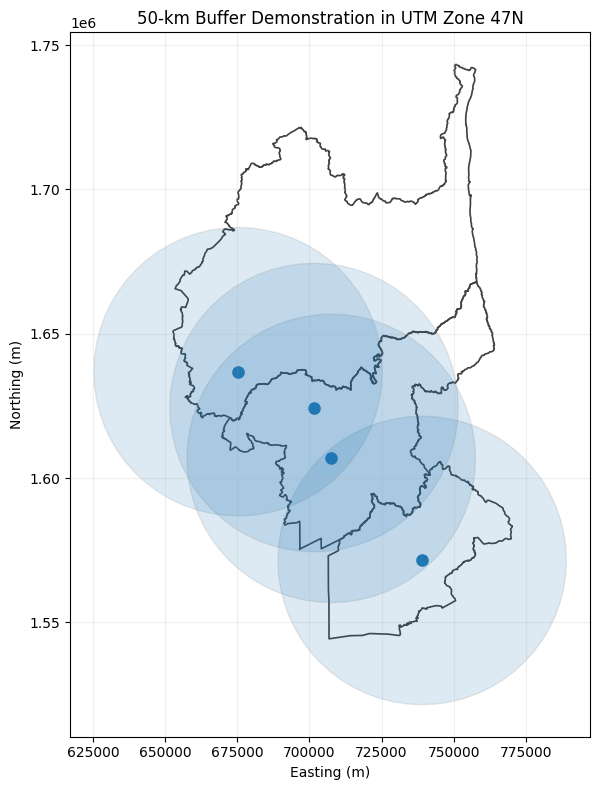

In [23]:
# CELL 23 — Plot projected map with buffer

fig, ax = plt.subplots(
    figsize=(
        9,
        8,
    )
)

case_provinces_utm.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.25",
    linewidth=1.2,
)

case_pcd_buffer50.plot(
    ax=ax,
    alpha=0.15,
    edgecolor="0.45",
)

case_pcd_utm.plot(
    ax=ax,
    markersize=65,
)


ax.set_xlabel(
    "Easting (m)"
)

ax.set_ylabel(
    "Northing (m)"
)

ax.set_title(
    "50-km Buffer Demonstration in UTM Zone 47N"
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

BUFFER_MAP = (
    FIGURE_DIR
    / "03_case_PCD_50km_buffer_UTM47N.png"
)

fig.savefig(
    BUFFER_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 3.16 Administrative Levels

ประเทศไทยมีพื้นที่การปกครองหลายระดับ

ใน course dataset:

```text
Province → จังหวัด
Amphoe   → อำเภอ
Tambon   → ตำบล
```

ระดับรายละเอียดเพิ่มขึ้น:

```text
Province
  ↓
Amphoe
  ↓
Tambon
```

จำนวน polygon จึงเพิ่มขึ้นตามระดับ

In [24]:
# CELL 24 — Administrative layer inventory

admin_inventory = pd.DataFrame([
    {
        "level":
            "Province",

        "feature_n":
            len(
                province
            ),

        "geometry":
            " | ".join(
                sorted(
                    province.geometry.geom_type.unique()
                )
            ),

        "crs":
            str(
                province.crs
            ),
    },

    {
        "level":
            "Amphoe",

        "feature_n":
            len(
                amphoe
            ),

        "geometry":
            " | ".join(
                sorted(
                    amphoe.geometry.geom_type.unique()
                )
            ),

        "crs":
            str(
                amphoe.crs
            ),
    },

    {
        "level":
            "Tambon",

        "feature_n":
            len(
                tambon
            ),

        "geometry":
            " | ".join(
                sorted(
                    tambon.geometry.geom_type.unique()
                )
            ),

        "crs":
            str(
                tambon.crs
            ),
    },
])


display(
    admin_inventory
)

,level,feature_n,geometry,crs
0,Province,77,MultiPolygon,EPSG:4326
1,Amphoe,928,MultiPolygon,EPSG:4326
2,Tambon,7425,MultiPolygon,EPSG:4326


In [25]:
# CELL 25 — Select amphoe and tambon in the case-study provinces

if (
    "province_name_en"
    not in amphoe.columns
    or "province_name_en"
    not in tambon.columns
):

    raise KeyError(
        "province_name_en is required in amphoe and tambon layers."
    )


case_amphoe = (
    amphoe[
        amphoe[
            "province_name_en"
        ].isin(
            CASE_PROVINCES
        )
    ]
    .copy()
)


case_tambon = (
    tambon[
        tambon[
            "province_name_en"
        ].isin(
            CASE_PROVINCES
        )
    ]
    .copy()
)


print(
    "Case provinces:",
    len(
        case_provinces
    )
)

print(
    "Case amphoe:",
    len(
        case_amphoe
    )
)

print(
    "Case tambon:",
    len(
        case_tambon
    )
)

Case provinces: 3
Case amphoe: 28
Case tambon: 276


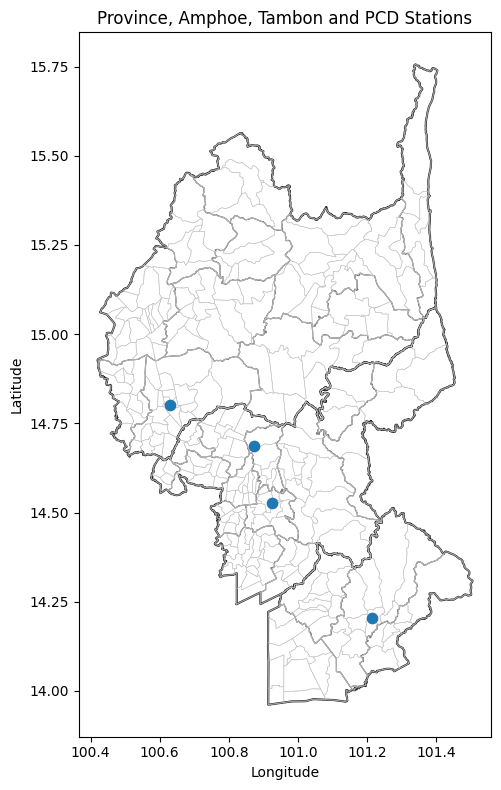

In [26]:
# CELL 26 — Multi-level administrative map

fig, ax = plt.subplots(
    figsize=(
        9,
        8,
    )
)

case_provinces.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.15",
    linewidth=1.5,
)

case_amphoe.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.5",
    linewidth=0.8,
)

case_tambon.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.75",
    linewidth=0.35,
)

case_pcd.plot(
    ax=ax,
    markersize=55,
)


xmin, ymin, xmax, ymax = (
    case_provinces.total_bounds
)

xpad = (
    xmax
    - xmin
) * 0.05

ypad = (
    ymax
    - ymin
) * 0.05

ax.set_xlim(
    xmin - xpad,
    xmax + xpad,
)

ax.set_ylim(
    ymin - ypad,
    ymax + ypad,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "Province, Amphoe, Tambon and PCD Stations"
)

fig.tight_layout()

ADMIN_LEVEL_MAP = (
    FIGURE_DIR
    / "03_admin_levels_case_provinces.png"
)

fig.savefig(
    ADMIN_LEVEL_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 3.17 Geometry Quality Control

Spatial data อาจมีปัญหา:

```text
missing geometry
invalid polygon
empty geometry
unexpected geometry type
wrong CRS
wrong bounds
```

ก่อน spatial analysis ควรตรวจ geometry

ตัวอย่าง:

```python
gdf.geometry.is_valid
gdf.geometry.is_empty
gdf.total_bounds
```

In [27]:
# CELL 27 — Geometry QC function

def geometry_qc(
    gdf,
    layer_name,
):
    bounds = (
        gdf.total_bounds
        if len(
            gdf
        ) > 0
        else [
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        ]
    )

    return {
        "layer":
            layer_name,

        "feature_n":
            len(
                gdf
            ),

        "missing_geometry_n":
            int(
                gdf.geometry.isna().sum()
            ),

        "empty_geometry_n":
            int(
                gdf.geometry.is_empty.sum()
            ),

        "invalid_geometry_n":
            int(
                (
                    ~gdf.geometry.is_valid
                )
                .fillna(
                    True
                )
                .sum()
            ),

        "geometry_types":
            " | ".join(
                sorted(
                    gdf.geometry.geom_type.dropna().unique()
                )
            ),

        "crs":
            str(
                gdf.crs
            ),

        "minx":
            bounds[
                0
            ],

        "miny":
            bounds[
                1
            ],

        "maxx":
            bounds[
                2
            ],

        "maxy":
            bounds[
                3
            ],
    }


geometry_qc_report = pd.DataFrame([
    geometry_qc(
        province,
        "province",
    ),

    geometry_qc(
        amphoe,
        "amphoe",
    ),

    geometry_qc(
        tambon,
        "tambon",
    ),

    geometry_qc(
        pcd_gpkg,
        "pcd_stations",
    ),

    geometry_qc(
        ogimet_gpkg,
        "ogimet_stations",
    ),
])


display(
    geometry_qc_report
)

,layer,feature_n,missing_geometry_n,empty_geometry_n,invalid_geometry_n,geometry_types,crs,minx,miny,maxx,maxy
0,province,77,0,0,0,MultiPolygon,EPSG:4326,97.343358,5.613038,105.636965,20.465029
1,amphoe,928,0,0,0,MultiPolygon,EPSG:4326,97.343478,5.613038,105.636965,20.465029
2,tambon,7425,0,0,0,MultiPolygon,EPSG:4326,97.343578,5.613038,105.636965,20.464722
3,pcd_stations,173,0,0,0,Point,EPSG:4326,97.971650,5.763873,104.846219,20.427325
4,ogimet_stations,130,0,0,0,Point,EPSG:4326,97.933333,6.426667,105.033056,19.961389


# 3.18 Map Bounds

`total_bounds` ให้:

```text
minx, miny, maxx, maxy
```

สำหรับ EPSG:4326:

```text
minx / maxx → longitude
miny / maxy → latitude
```

ประเทศไทยโดยประมาณควรอยู่ในช่วง:

```text
longitude ~ 97–106°E
latitude  ~ 5–21°N
```

ถ้าพบ:

```text
longitude = 14
latitude  = 100
```

มีโอกาสสูงว่าสลับ latitude/longitude

In [28]:
# CELL 28 — Bounds sanity check

bounds_checks = []

for layer_name, gdf in [
    (
        "province",
        province,
    ),
    (
        "pcd_stations",
        pcd_gpkg,
    ),
    (
        "ogimet_stations",
        ogimet_gpkg,
    ),
]:

    minx, miny, maxx, maxy = (
        gdf.to_crs(
            4326
        ).total_bounds
    )

    broadly_thailand = (
        minx >= 95
        and maxx <= 108
        and miny >= 3
        and maxy <= 23
    )

    bounds_checks.append({
        "layer":
            layer_name,

        "min_longitude":
            minx,

        "min_latitude":
            miny,

        "max_longitude":
            maxx,

        "max_latitude":
            maxy,

        "broad_thailand_bounds":
            broadly_thailand,
    })


bounds_qc = pd.DataFrame(
    bounds_checks
)

display(
    bounds_qc
)

,layer,min_longitude,min_latitude,max_longitude,max_latitude,broad_thailand_bounds
0,province,97.343358,5.613038,105.636965,20.465029,True
1,pcd_stations,97.971650,5.763873,104.846219,20.427325,True
2,ogimet_stations,97.933333,6.426667,105.033056,19.961389,True


# 3.19 Meteorological Stations

สถานีอุตุนิยมวิทยาเป็น Point เช่นเดียวกับ PCD station

แต่มีบทบาทต่างกัน:

```text
PCD station
→ air-quality observation

OGIMET/WMO station
→ meteorological observation
```

ใน Notebook 04 เราจะตั้งคำถาม:

> ควรจับคู่ PCD station กับ meteorological station ใด?

ก่อนถึงขั้นนั้น เราต้องเข้าใจ distribution ของทั้งสอง network ก่อน

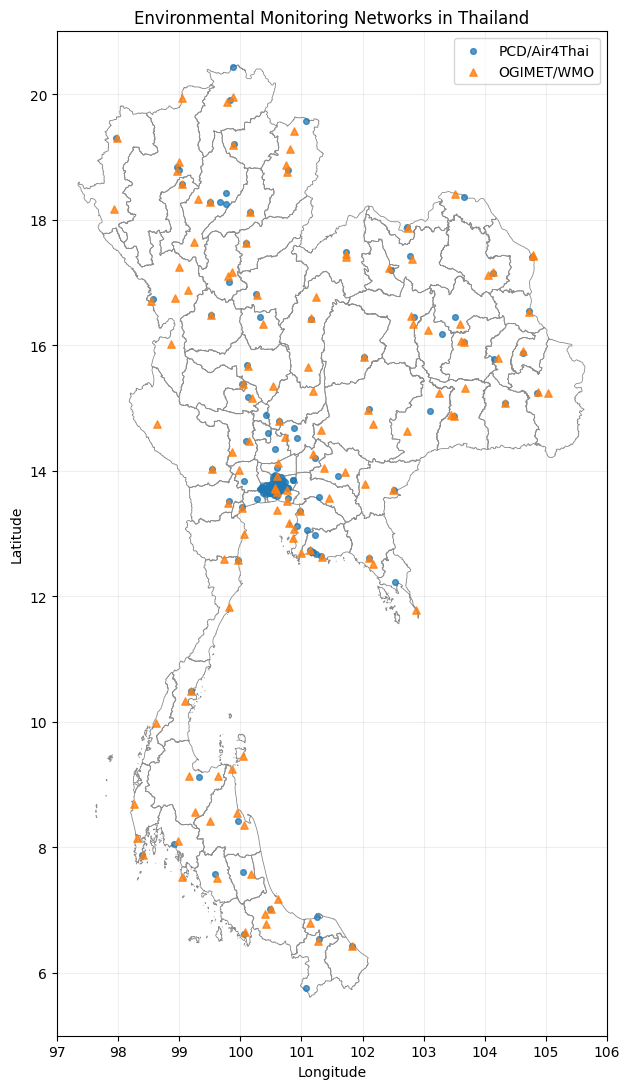

In [29]:
# CELL 29 — PCD and OGIMET station network map

fig, ax = plt.subplots(
    figsize=(
        8.5,
        11,
    )
)

province.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.55",
    linewidth=0.6,
)

pcd_gpkg.plot(
    ax=ax,
    markersize=17,
    alpha=0.75,
    label="PCD/Air4Thai",
)

ogimet_gpkg.plot(
    ax=ax,
    marker="^",
    markersize=28,
    alpha=0.8,
    label="OGIMET/WMO",
)


ax.set_xlim(
    97,
    106,
)

ax.set_ylim(
    5,
    21,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "Environmental Monitoring Networks in Thailand"
)

ax.grid(
    alpha=0.2
)

ax.legend()

fig.tight_layout()

NETWORK_MAP = (
    FIGURE_DIR
    / "03_PCD_OGIMET_networks_Thailand.png"
)

fig.savefig(
    NETWORK_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# ตีความ network map

จากแผนที่ควรถาม:

```text
PCD และ WMO stations กระจายสม่ำเสมอหรือไม่?
มีพื้นที่ใด station หนาแน่น?
มีพื้นที่ใด station ห่างกันมาก?
PCD station มี WMO station อยู่ใกล้เสมอหรือไม่?
```

แต่ยังไม่ควรตอบด้วย “สายตา” เพียงอย่างเดียว

Notebook 04 จะวัด distance และทำ nearest-station matching

# 3.20 เชื่อม PM₂.₅ จาก Notebook 02 เข้ากับแผนที่

Notebook 02 สร้าง:

```text
02_pcd_pm25_daily_2021_2025.csv.gz
```

ไฟล์นี้มี PM₂.₅ รายวัน

เราจะยังไม่ทำ spatiotemporal mapping แบบเต็มรูปแบบ
แต่จะทดลอง:

```text
เลือก 1 ปี
→ mean PM2.5 per station
→ merge กับ station geometry
→ map
```

เพื่อให้เห็นว่า:

```text
Attribute + Geometry
```

รวมกันอย่างไร

In [30]:
# CELL 30 — Read daily PM2.5 output from Notebook 02

if (
    PM25_DAILY_FILE is None
    or not PM25_DAILY_FILE.exists()
):

    print(
        "Notebook 02 daily PM2.5 output was not found."
    )

    print(
        "PM2.5 mapping example will be skipped."
    )

    pm25_daily = pd.DataFrame()

else:

    pm25_daily = pd.read_csv(
        PM25_DAILY_FILE,
        dtype={
            "station_id":
                "string"
        },
        parse_dates=[
            "date"
        ],
    )

    pm25_daily[
        "station_id"
    ] = (
        pm25_daily[
            "station_id"
        ]
        .astype(
            "string"
        )
        .str.strip()
        .str.lower()
    )

    print(
        "Daily PM2.5 rows:",
        len(
            pm25_daily
        )
    )

    print(
        "Years:"
    )

    print(
        sorted(
            pm25_daily[
                "year"
            ]
            .dropna()
            .unique()
        )
    )

Daily PM2.5 rows: 70173
Years:
[np.int64(2024), np.int64(2025)]


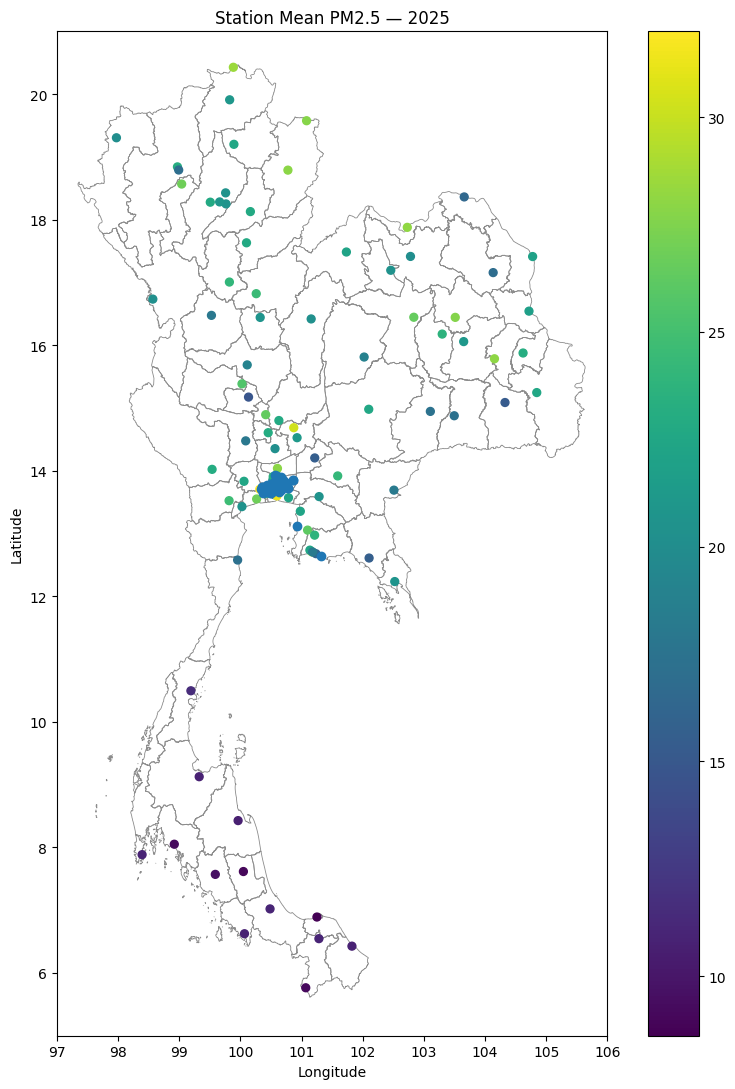

In [31]:
# CELL 31 — Example station-mean PM2.5 map for one year

if len(
    pm25_daily
) > 0:

    AVAILABLE_YEARS = sorted(
        pm25_daily[
            "year"
        ]
        .dropna()
        .astype(int)
        .unique()
    )


    MAP_YEAR = (
        AVAILABLE_YEARS[
            -1
        ]
    )


    station_year_pm25 = (
        pm25_daily[
            pm25_daily[
                "year"
            ].eq(
                MAP_YEAR
            )
        ]
        .groupby(
            "station_id"
        )
        .agg(
            mean_pm25=(
                "pm25_mean",
                "mean",
            ),

            observed_days=(
                "date",
                "nunique",
            ),
        )
        .reset_index()
    )


    pcd_year_map = (
        pcd_gpkg
        .merge(
            station_year_pm25,
            on="station_id",
            how="left",
            validate="one_to_one",
        )
    )


    fig, ax = plt.subplots(
        figsize=(
            8.5,
            11,
        )
    )

    province.plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.55",
        linewidth=0.6,
    )

    pcd_year_map.plot(
        ax=ax,
        column="mean_pm25",
        legend=True,
        markersize=32,
        missing_kwds={
            "label":
                "No PM2.5 data",
        },
    )

    ax.set_xlim(
        97,
        106,
    )

    ax.set_ylim(
        5,
        21,
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.set_title(
        f"Station Mean PM2.5 — {MAP_YEAR}"
    )

    fig.tight_layout()

    PM25_MAP = (
        FIGURE_DIR
        / (
            f"03_station_mean_PM25_"
            f"{MAP_YEAR}.png"
        )
    )

    fig.savefig(
        PM25_MAP,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

else:

    pcd_year_map = gpd.GeoDataFrame()

# ข้อควรระวังในการอ่าน PM₂.₅ station map

สีของ Point แสดง:

```text
mean PM2.5 at monitoring station
```

ไม่ได้แสดง:

```text
continuous PM2.5 surface across Thailand
```

พื้นที่ระหว่าง station ไม่มีค่าที่วัดโดยตรง

ดังนั้นไม่ควรระบายพื้นที่จังหวัดด้วยค่าของสถานีหนึ่งแห่งแล้วเรียกว่า:

> “ค่า PM₂.₅ ของทั้งจังหวัด”

โดยไม่มีวิธีประมาณค่าหรือ sampling design รองรับ

# 3.21 Save GIS Teaching Outputs

Notebook นี้จะบันทึก:

```text
03_geometry_QC.csv
03_CRS_inventory.csv
03_bounds_QC.csv
03_admin_inventory.csv
03_case_PCD_projected_coordinates.csv
```

และ GeoPackage สำหรับ case study:

```text
03_case_study_layers.gpkg
```

ประกอบด้วย:

```text
case_provinces
case_amphoe
case_tambon
case_pcd_stations
```

เพื่อใช้ต่อใน Notebook 04

In [32]:
# CELL 32 — Save tabular GIS diagnostics

TABLE_OUTPUTS = {
    "03_GeoPackage_layers.csv":
        layer_table,

    "03_CRS_inventory.csv":
        crs_inventory,

    "03_geometry_QC.csv":
        geometry_qc_report,

    "03_bounds_QC.csv":
        bounds_qc,

    "03_admin_inventory.csv":
        admin_inventory,

    "03_case_PCD_projected_coordinates.csv":
        projected_coordinate_table.drop(
            columns="geometry",
            errors="ignore",
        ),
}


for filename, table in TABLE_OUTPUTS.items():

    path = (
        OUTPUT_DIR
        / filename
    )

    table.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "Saved:",
        filename
    )

Saved: 03_GeoPackage_layers.csv
Saved: 03_CRS_inventory.csv
Saved: 03_geometry_QC.csv
Saved: 03_bounds_QC.csv
Saved: 03_admin_inventory.csv
Saved: 03_case_PCD_projected_coordinates.csv


In [33]:
# CELL 33 — Save case-study GeoPackage

CASE_GPKG = (
    OUTPUT_DIR
    / "03_case_study_layers.gpkg"
)


if CASE_GPKG.exists():

    CASE_GPKG.unlink()


case_provinces.to_file(
    CASE_GPKG,
    layer="case_provinces",
    driver="GPKG",
)

case_amphoe.to_file(
    CASE_GPKG,
    layer="case_amphoe",
    driver="GPKG",
    mode="a",
)

case_tambon.to_file(
    CASE_GPKG,
    layer="case_tambon",
    driver="GPKG",
    mode="a",
)

case_pcd.to_file(
    CASE_GPKG,
    layer="case_pcd_stations",
    driver="GPKG",
    mode="a",
)


print(
    "Saved:",
    CASE_GPKG
)

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_03/03_case_study_layers.gpkg


# 3.22 Final GIS Readiness Check

Notebook 03 พร้อมสำหรับ Notebook 04 เมื่อ:

```text
Province/Amphoe/Tambon readable
PCD points readable
OGIMET points readable
CRS available
EPSG:4326 consistent
geometry valid
case provinces found
PCD case stations found
UTM reprojection succeeds
case GeoPackage saved
```

In [34]:
# CELL 34 — Final Notebook 03 checkpoint

all_base_crs_4326 = (
    crs_inventory[
        "crs"
    ]
    .astype(str)
    .str.contains(
        "4326",
        regex=False,
    )
    .all()
)


all_geometry_valid = (
    geometry_qc_report[
        "invalid_geometry_n"
    ]
    .eq(
        0
    )
    .all()
)


final_checks = pd.DataFrame([
    {
        "check":
            "Required GIS layers",

        "status":
            (
                "PASS"
                if len(
                    missing_layers
                ) == 0
                else "FAIL"
            ),

        "detail":
            (
                "all found"
                if len(
                    missing_layers
                ) == 0
                else ", ".join(
                    missing_layers
                )
            ),
    },

    {
        "check":
            "Canonical CRS EPSG:4326",

        "status":
            (
                "PASS"
                if all_base_crs_4326
                else "FAIL"
            ),

        "detail":
            str(
                list(
                    crs_inventory[
                        "crs"
                    ]
                )
            ),
    },

    {
        "check":
            "Valid geometries",

        "status":
            (
                "PASS"
                if all_geometry_valid
                else "FAIL"
            ),

        "detail":
            str(
                int(
                    geometry_qc_report[
                        "invalid_geometry_n"
                    ].sum()
                )
            ),
    },

    {
        "check":
            "Case provinces = 3",

        "status":
            (
                "PASS"
                if len(
                    case_provinces
                ) == 3
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    case_provinces
                )
            ),
    },

    {
        "check":
            "Case PCD stations available",

        "status":
            (
                "PASS"
                if len(
                    case_pcd
                ) > 0
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    case_pcd
                )
            ),
    },

    {
        "check":
            "UTM 47N reprojection",

        "status":
            (
                "PASS"
                if (
                    case_pcd_utm.crs
                    is not None
                    and "32647"
                    in str(
                        case_pcd_utm.crs
                    )
                )
                else "FAIL"
            ),

        "detail":
            str(
                case_pcd_utm.crs
            ),
    },

    {
        "check":
            "Case-study GeoPackage saved",

        "status":
            (
                "PASS"
                if CASE_GPKG.exists()
                else "FAIL"
            ),

        "detail":
            str(
                CASE_GPKG
            ),
    },
])


display(
    final_checks
)


if final_checks[
    "status"
].eq(
    "PASS"
).all():

    print(
        "\n=================================="
    )

    print(
        "NOTEBOOK 03 GIS FOUNDATIONS READY"
    )

    print(
        "=================================="
    )

else:

    print(
        "\nCHECK GIS DATA BEFORE NOTEBOOK 04"
    )

,check,status,detail
0,Required GIS layers,PASS,all found
1,Canonical CRS EPSG:4326,PASS,"['EPSG:4326', 'EPSG:4326', 'EPSG:4326', 'EPSG:..."
2,Valid geometries,PASS,0
3,Case provinces = 3,PASS,3
4,Case PCD stations available,PASS,4
5,UTM 47N reprojection,PASS,EPSG:32647
6,Case-study GeoPackage saved,PASS,/content/drive/MyDrive/Teaching_PCD_Environmen...



NOTEBOOK 03 GIS FOUNDATIONS READY


# แบบฝึกหัดท้ายบท

## Exercise 1 — Point, Line, Polygon

จำแนกสิ่งต่อไปนี้:

```text
PCD station
WMO station
province
river
road
tambon
storm track
```

ว่าเหมาะกับ:

```text
Point
Line
Polygon
```

---

## Exercise 2 — Longitude / Latitude

เลือก PCD station 3 แห่ง

รายงาน:

```text
station_id
longitude
latitude
```

แล้วตอบ:

```text
X คืออะไร?
Y คืออะไร?
```

---

## Exercise 3 — CRS

อธิบายความแตกต่าง:

```text
EPSG:4326
EPSG:32647
```

ในหัวข้อ:

```text
coordinate type
unit
appropriate use
distance calculation
```

---

## Exercise 4 — Wrong Distance

ลองคำนวณ distance ระหว่าง 2 stations ใน EPSG:4326

จากนั้น reproject เป็น EPSG:32647 แล้วคำนวณใหม่

ตอบ:

> เพราะเหตุใดค่าชุดแรกจึงไม่ควรถูกเรียกว่า kilometre?

---

## Exercise 5 — Administrative Scale

เปรียบเทียบจำนวน:

```text
Province
Amphoe
Tambon
```

ใน 3 จังหวัดกรณีศึกษา

อธิบายว่า:

> ทำไมรายละเอียดของแผนที่จึงเพิ่มขึ้นเมื่อใช้หน่วยพื้นที่เล็กลง?

---

## Exercise 6 — Monitoring Network

จากแผนที่ PCD + OGIMET/WMO ตอบ:

1. network ทั้งสองมีความหนาแน่นเท่ากันหรือไม่?
2. ทุก PCD station มี WMO station อยู่ใกล้หรือไม่?
3. เราสามารถเลือก WMO station ที่ “ใกล้ที่สุด” ด้วยสายตาได้อย่างน่าเชื่อถือหรือไม่?

คำถามข้อ 3 จะเป็นหัวข้อของ Notebook 04

---

## Exercise 7 — PM₂.₅ Point Map

เลือกปีหนึ่ง

สร้าง station mean PM₂.₅ map

จากนั้นเขียนคำอธิบาย 3 ประโยค โดยต้องแยก:

```text
สิ่งที่แผนที่แสดง
สิ่งที่แผนที่ไม่แสดง
ข้อจำกัดของ station network
```

# Common GIS Mistakes

## Mistake 1

```python
gpd.points_from_xy(
    latitude,
    longitude
)
```

ผิด

ควรเป็น:

```python
gpd.points_from_xy(
    longitude,
    latitude
)
```

---

## Mistake 2

คำนวณ buffer:

```python
gdf.buffer(50)
```

ใน EPSG:4326 แล้วตีความว่า 50 km

ผิด เพราะหน่วยคือ degree

---

## Mistake 3

เปลี่ยน CRS ด้วย:

```python
gdf.set_crs("EPSG:32647")
```

เมื่อ geometry จริงยังเป็น longitude/latitude

`set_crs()` คือการ **กำหนดความหมายให้ coordinate เดิม**

ส่วน:

```python
gdf.to_crs("EPSG:32647")
```

คือการ **แปลง coordinate**

สองคำสั่งนี้ไม่เหมือนกัน

---

## Mistake 4

เห็น Point อยู่ใน Polygon แล้วสรุปด้วยสายตาโดยไม่ spatial join

สำหรับงานจริงควรใช้ spatial operation ตรวจอย่างเป็นระบบ

---

## Mistake 5

เห็นพื้นที่ไม่มี station แล้วสรุปว่า pollution ต่ำ

ไม่มี station ≠ pollution ต่ำ

# สิ่งที่ต้องจำจาก Notebook 03

```text
Spatial Data
=
Attribute
+
Geometry
+
CRS
```

และ:

```text
Longitude = X
Latitude  = Y
```

สำหรับ course canonical data:

```text
National storage / overview
→ EPSG:4326

Metric analysis in
Saraburi–Lop Buri–Nakhon Nayok
→ EPSG:32647
```

หลักสำคัญที่สุด:

> CRS ต้องเหมาะกับคำถามเชิงพื้นที่

ไม่ควรเลือก projection เพียงเพราะ code รันได้

# Notebook ต่อไป

## Notebook 04 — Spatial Join, Distance and Meteorological Station Matching

ชื่อที่แนะนำ:

```text
04_spatial_join_distance_and_station_matching.ipynb
```

คำถามหลัก:

```text
PCD station อยู่จังหวัด/อำเภอ/ตำบลใด?
        ↓
Spatial Join

PCD station อยู่ใกล้ WMO station ใด?
        ↓
Projected CRS
        ↓
Distance
        ↓
Nearest Station

PM2.5 station
        +
Meteorological station
        ↓
station pair
        ↓
date matching
        ↓
environmental interpretation
```

และจะเน้นข้อจำกัดว่า:

> nearest meteorological station  
> ไม่ได้แปลว่า representative meteorological station เสมอไป